In [1]:
# model libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# image reading libraries
import nibabel as nib
from nilearn import plotting as npl

import nitools as nt
from smarts_cerebellum import regression
from image_processing import overall_image
from image_processing import mirror_lesion
from image_processing import tissue_extractor as te
import smarts_cerebellum.globals as gl
from smarts_cerebellum.util import flip_left_lesion, make_summarized_dataframe

from image_processing import mirror_lesion

from pathlib import Path
import os

In [2]:
search_path = os.path.join(gl.baseDir, 'Regression')

p_df = pd.read_csv('/cifs/diedrichsen/data/smarts_cerebellum/participants_anat.tsv', sep = '\t')

left_lesion_df = p_df[p_df.LesionSide == 'left ']

flip_left_lesion(search_path, left_lesion_df, segment='T1')
flip_left_lesion(search_path, left_lesion_df, segment='GM')
flip_left_lesion(search_path, left_lesion_df, segment='WM')
flip_left_lesion(search_path, left_lesion_df, segment='logJac')

Skip CU_2697
Skip JHU_2374
Skip CU_2697
Skip JHU_2374
Skip CU_2697
Skip JHU_2374
Skip CU_2697
Skip JHU_2374


In [ ]:
df = make_summarized_dataframe(p_df = p_df,
                               search_path = search_path,
                               the_atlas = 'Diedrichsen_2009',
                               maps = 'atl-Anatom',
                               space = 'MNISym')
df.to_csv(os.path.join(search_path, 'MNISym_coreg_slope_AtlasSUIT_summarized.tsv'), sep='\t', index=False)

Writing data for CU_2310


KeyError: 0

In [5]:
df = pd.read_csv(os.path.join(search_path, 'MNISym_coreg_slope_AtlasSUIT_summarized.tsv'), sep='\t')

In [13]:
rois = ['Left_I_IV', 'Right_I_IV', 'Left_V', 'Right_V', 'Left_VI', 'Right_VI']
df_rois_CSF = df[df.regionname.isin(rois) & (df.image==1)]
df_rois_GM = df[df.regionname.isin(rois) & (df.image==4)]
df_rois_WM = df[df.regionname.isin(rois) & (df.image==3)]
df_rois_T1 = df[df.regionname.isin(rois) & (df.image==5)]
df_rois_logJac = df[df.regionname.isin(rois) & (df.image==2)]

<Axes: xlabel='regionname', ylabel='median'>

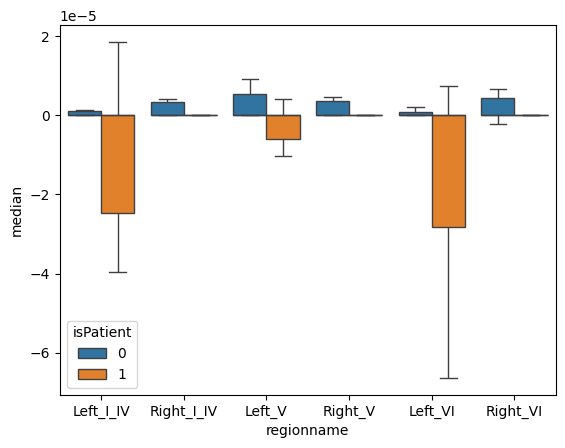

In [16]:
sns.boxplot(data=df_rois_GM, x='regionname', y='median', hue='isPatient', showfliers=False )

<Axes: xlabel='regionname', ylabel='median'>

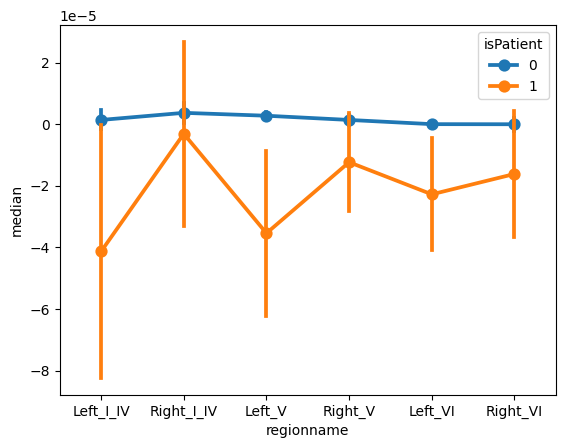

In [18]:
sns.pointplot(data=df_rois_GM, x='regionname', y='median', hue='isPatient', errorbar='se')